In [1]:
import numpy as np, random, os
import pandas as pd
from pipelines import *
from models import *
from visualisations import *

# seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [2]:
# prepare data for modeling
X_train_raw, X_test_raw, y_train, y_test, scaler, feature_names = prepare_data_for_modeling(verbose=True, scaled=False)
feature_names[:], len(feature_names), X_train_raw.shape, X_test_raw.shape

Loading data...
 courses: (22, 3)
 assessments: (206, 6)
 vle: (6364, 6)
 studentInfo: (32593, 12)
 studentRegistration: (32593, 5)
 studentAssessment: (173912, 5)
 studentVLE: (10655280, 6)


(['is_male',
  'age_numeric',
  'education_numeric',
  'has_disability',
  'imd_numeric',
  'studied_credits',
  'num_of_prev_attempts',
  'days_since_last_login',
  'early_failed_any',
  'days_enrolled_before_course',
  'course_difficulty',
  'relative_assessment_performance',
  'relative_total_clicks',
  'relative_days_active'],
 14,
 (21001, 14),
 (5251, 14))

## Part 2A: Rule Based Prediction: Baseline
This model represents the current solution at many universities, including the University of Adelaide and the Unviersity of South Australia. Students are predicted as being 'at risk' of failure based on a rule, usually not having logged in to one or more courses for a period of 7-10 days prior to Census day.

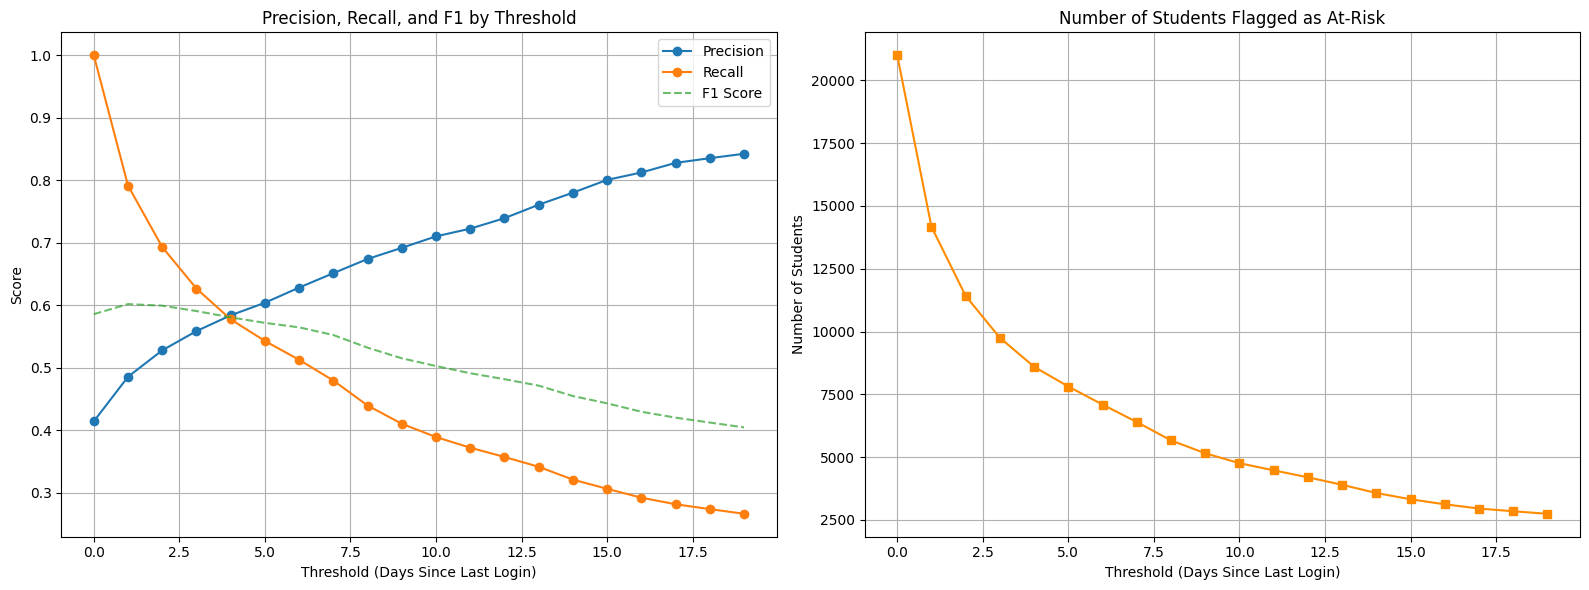

In [3]:
thresholds = list(range(0, 20))
df_base = run_baseline_sweep(X_train_raw, y_train, thresholds, feature_name="days_since_last_login")
plot_baseline_sweep(df_base)

✅ Baseline model '10-Day Rule' run in 0.0s

10-Day Rule Performance Summary
----------------------------------------
 Precision : 0.71
 Recall    : 0.39
 F1 Score  : 0.50
 PR-AUC    : 0.53


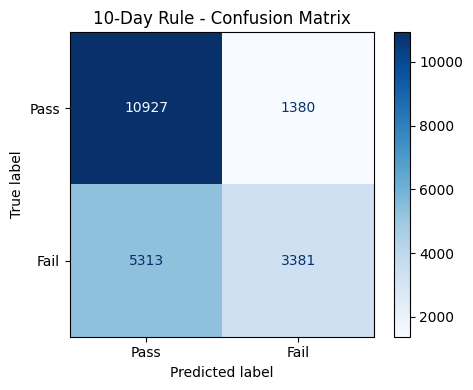

In [4]:
results_list = []
baseline_result = run_baseline_model(X_train_raw, y_train, threshold_days=10)
results_list.insert(0, baseline_result)
print_model_report(baseline_result["name"], baseline_result)

## Part 2B: Machine Learning 
These models represent a hypothetical future solution for universities around Autralia.

In [5]:
# prepare scaled data for ML modeling
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_data_for_modeling()

✅ Logistic Regression trained in 1.6s

Logistic Regression Performance Summary
----------------------------------------
 Precision : 0.76
 Recall    : 0.59
 F1 Score  : 0.66
 PR-AUC    : 0.80


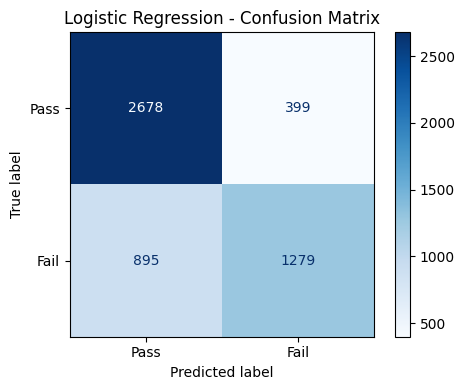

In [6]:
best_log_reg = gridsearch_logistic_model(X_train, y_train)
res_logreg = evaluate_model(best_log_reg, X_test, y_test, "Logistic Regression")
results_list.append(res_logreg)
print_model_report(res_logreg["name"], res_logreg)

✅ Random Forest trained in 48.3s

Random Forest Performance Summary
----------------------------------------
 Precision : 0.76
 Recall    : 0.60
 F1 Score  : 0.67
 PR-AUC    : 0.79


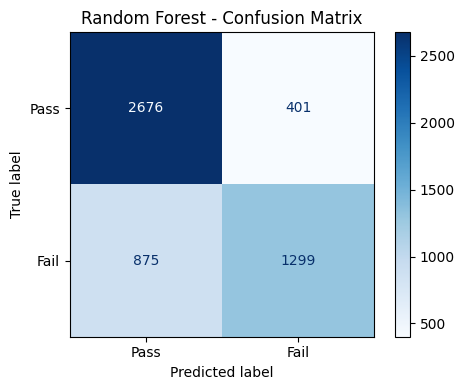

In [7]:
best_rf = gridsearch_random_forest_model(X_train, y_train)
res_rf = evaluate_model(best_rf, X_test, y_test, "Random Forest")
results_list.append(res_rf)
print_model_report(res_rf["name"], res_rf)

✅ MLP trained in 5.2s

MLP Performance Summary
----------------------------------------
 Precision : 0.78
 Recall    : 0.60
 F1 Score  : 0.68
 PR-AUC    : 0.79


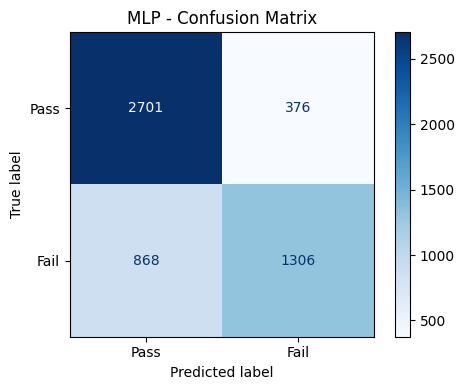

In [8]:
best_mlp = gridsearch_mlp_model(X_train, y_train)
res_mlp = evaluate_model(best_mlp, X_test, y_test, "MLP")
results_list.append(res_mlp)
print_model_report(res_mlp["name"], res_mlp)

CNN configuration: hidden_units=(64, 32), dropout_rate=0.2, learning_rate=0.1

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step
   Mean F1 = 0.67

CNN configuration: hidden_units=(64, 32), dropout_rate=0.2, learning_rate=0.01

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step
   Mean F1 = 0.68

CNN configuration: hidden_units=(64, 32), dropout_rate=0.4, learning_rate=0.1

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step
   Mean F1 = 0.68

CNN configuration: hidden_units=(64, 32), dropout_rate=0.4, 

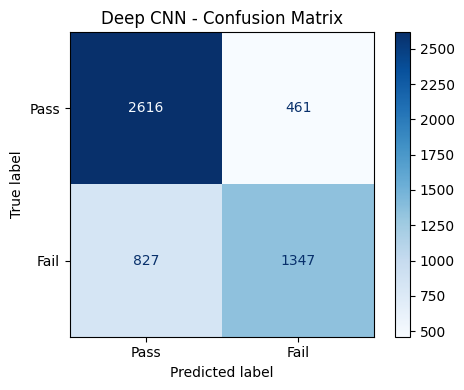

In [9]:
cnn = CNNModel(input_dim=X_train.shape[1])
best_cnn = cnn.gridsearch(X_train, y_train)
res_cnn = evaluate_model(best_cnn, X_test, y_test, "Deep CNN")
results_list.append(res_cnn)
print_model_report(res_cnn["name"], res_cnn)

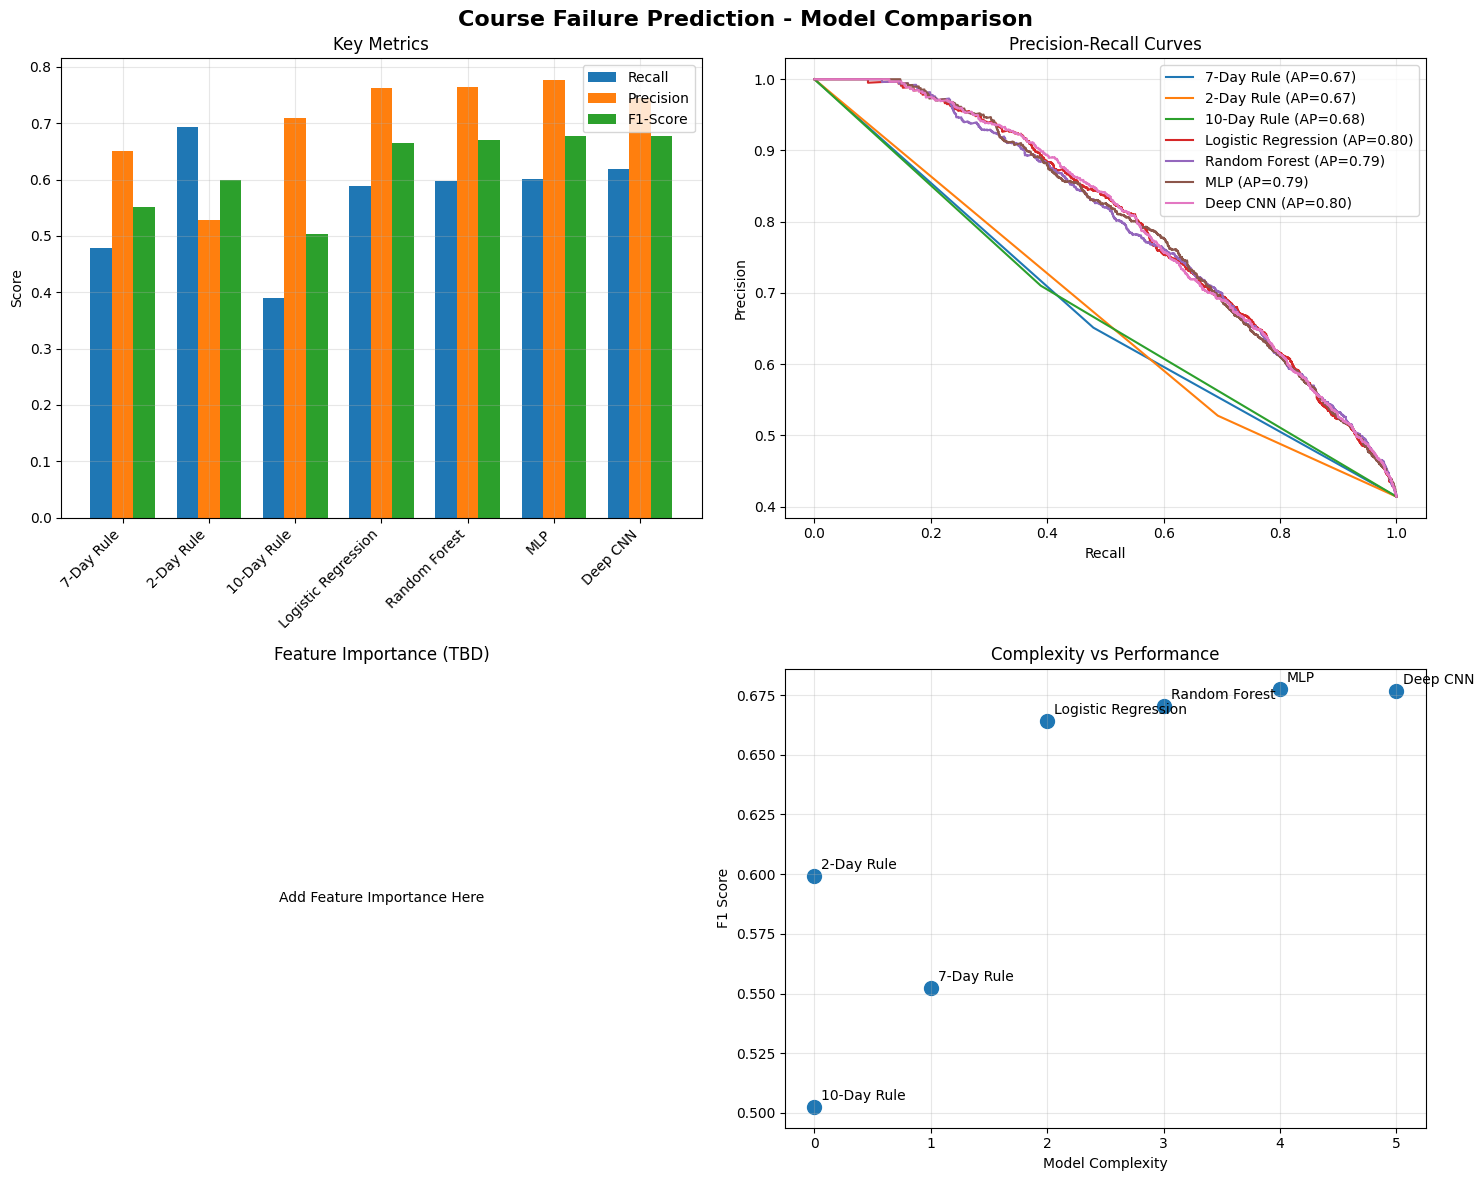

,Model,Precision,Recall,F1,PR_AUC
5,MLP,0.776457,0.600736,0.677386,0.794338
6,Deep CNN,0.745022,0.619595,0.676544,0.796505
4,Random Forest,0.764118,0.597516,0.670625,0.792467
3,Logistic Regression,0.762217,0.588316,0.664071,0.795750
1,2-Day Rule,0.527676,0.693007,0.599145,0.492772
0,7-Day Rule,0.651195,0.479296,0.552177,0.527677
2,10-Day Rule,0.710145,0.388889,0.502564,0.529155


In [14]:
plot_model_comparison(results_list)
pd.DataFrame([{"Model": r["name"], **r["metrics"]} for r in results_list]).sort_values("F1", ascending=False)

In [16]:
for result in results_list:
    print_brief_metrics(result["name"], result)

7-Day Rule           | Precision: 0.65 | Recall: 0.48 | F1: 0.55 | PR-AUC: 0.53
2-Day Rule           | Precision: 0.53 | Recall: 0.69 | F1: 0.60 | PR-AUC: 0.49
10-Day Rule          | Precision: 0.71 | Recall: 0.39 | F1: 0.50 | PR-AUC: 0.53
Logistic Regression  | Precision: 0.76 | Recall: 0.59 | F1: 0.66 | PR-AUC: 0.80
Random Forest        | Precision: 0.76 | Recall: 0.60 | F1: 0.67 | PR-AUC: 0.79
MLP                  | Precision: 0.78 | Recall: 0.60 | F1: 0.68 | PR-AUC: 0.79
Deep CNN             | Precision: 0.75 | Recall: 0.62 | F1: 0.68 | PR-AUC: 0.80
